# Rifiuti per km² — dove si produce di più?

**Dataset**: `ispra_ru_base` (ISPRA Rifiuti Urbani 2020-2024) + `istat_elenco_comuni` (superficie km²)

**Vedi README completo**: `analisi/rifiuti-km2/README.md`

---

**Nota sul join**: i codici ISTAT dei comuni sardi sono cambiati dopo la riforma
provinciale del 2016-2021. ISPRA usa i vecchi codici, ISTAT SITUAS 2026 i nuovi.
Per Sardegna si usa un join per nome normalizzato (strip non-ASCII).
3 comuni non-Sardegna non hanno corrispondenza (cessati/fusi): Lirio (PV),
Castegnero (VI), Nanto (VI). Copertura: 7.668/7.671 comuni (99,96%).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

con = duckdb.connect()
BASE = 'gs://dataciviclab-clean/ispra_ru_base/*/ispra_ru_base_*_clean.parquet'
SUP  = 'gs://dataciviclab-clean/istat_elenco_comuni/2026/istat_elenco_comuni_2026_clean.parquet'
FIGS = Path('../figures')
FIGS.mkdir(parents=True, exist_ok=True)

# Vista materializzata del join (codice + nome normalizzato per Sardegna)
con.execute(f"""
    CREATE OR REPLACE TEMP VIEW joined AS
    SELECT r.*, s.superficie_km2 FROM '{BASE}' r
    JOIN '{SUP}' s ON SUBSTR(r.codice_comune_istat, 3, 6) = s.codice_istat
    WHERE r.regione != 'Sardegna'
    UNION ALL
    SELECT r.*, s.superficie_km2 FROM '{BASE}' r
    JOIN '{SUP}' s
        ON REGEXP_REPLACE(UPPER(TRIM(r.comune)), '[^A-Z]', '', 'g') = REGEXP_REPLACE(UPPER(TRIM(s.denominazione)), '[^A-Z]', '', 'g')
    WHERE r.regione = 'Sardegna'
""")
print("Vista joined creata")

Vista joined creata


## 1. Copertura e verifica join

In [2]:
# Copertura del join
df_join_check = con.execute("""
    SELECT anno, COUNT(DISTINCT codice_comune_istat) as comuni_join
    FROM joined GROUP BY anno ORDER BY anno
""").df()
df_full = con.execute(f"""
    SELECT anno, COUNT(DISTINCT codice_comune_istat) as comuni_totali
    FROM '{BASE}' GROUP BY anno ORDER BY anno
""").df()
df_check = df_full.merge(df_join_check, on='anno')
df_check['persi'] = df_check['comuni_totali'] - df_check['comuni_join']
df_check['copertura'] = (df_check['comuni_join'] / df_check['comuni_totali'] * 100).round(1)
display(df_check)

,anno,comuni_totali,comuni_join,persi,copertura
0,2020,7628,7594,34,99.6
1,2021,7618,7601,17,99.8
2,2022,7631,7599,32,99.6
3,2023,7669,7659,10,99.9
4,2024,7671,7667,4,99.9


## 2. Trend nazionale RD 2020-2024

In [3]:
df_naz = con.execute("""
    SELECT anno,
           ROUND(SUM(totale_rd_tonnellate) / NULLIF(SUM(totale_ru_tonnellate), 0) * 100, 1) as rd_pct,
           ROUND(SUM(totale_ru_tonnellate)) as tot_ru_ton,
           ROUND(SUM(totale_ru_tonnellate) / NULLIF(SUM(popolazione), 0) * 1000, 0) as kg_procapite
    FROM joined WHERE popolazione > 0
    GROUP BY anno ORDER BY anno
""").df()
display(df_naz)

,anno,rd_pct,tot_ru_ton,kg_procapite
0,2020,62.9,28481655.0,489.0
1,2021,64.0,29135818.0,503.0
2,2022,65.1,28562047.0,494.0
3,2023,66.6,28826202.0,496.0
4,2024,67.6,29516276.0,508.0


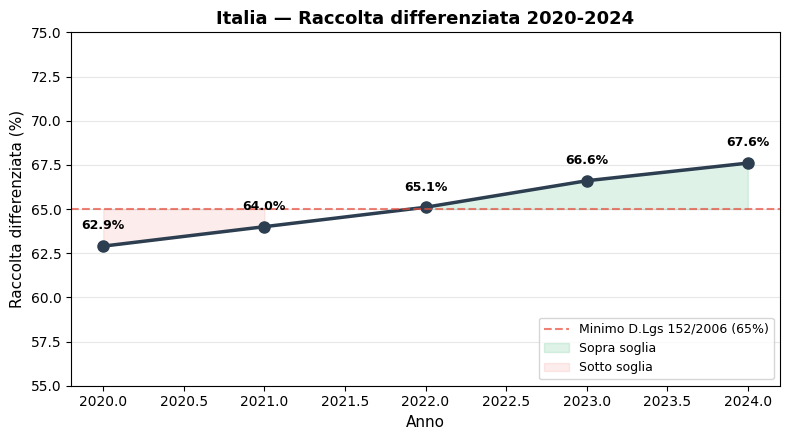

In [4]:
# Figura 1: Trend RD nazionale
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_naz['anno'], df_naz['rd_pct'], marker='o', linewidth=2.5, color='#2c3e50', markersize=8)
ax.axhline(y=65, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7, label='Minimo D.Lgs 152/2006 (65%)')
ax.fill_between(df_naz['anno'], 65, df_naz['rd_pct'],
                where=(df_naz['rd_pct'] >= 65), color='#27ae60', alpha=0.15, label='Sopra soglia')
ax.fill_between(df_naz['anno'], 65, df_naz['rd_pct'],
                where=(df_naz['rd_pct'] < 65), color='#e74c3c', alpha=0.1, label='Sotto soglia')
ax.set_ylim(55, 75)
ax.set_xlabel('Anno', fontsize=11)
ax.set_ylabel('Raccolta differenziata (%)', fontsize=11)
ax.set_title('Italia — Raccolta differenziata 2020-2024', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)
for _, r in df_naz.iterrows():
    ax.annotate(f"{r['rd_pct']}%", (r['anno'], r['rd_pct']),
                textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_trend_rd_nazionale.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Raccolta differenziata per regione (2024)

In [5]:
df_reg = con.execute("""
    SELECT regione,
           COUNT(DISTINCT codice_comune_istat) as comuni,
           ROUND(SUM(totale_rd_tonnellate) / NULLIF(SUM(totale_ru_tonnellate), 0) * 100, 1) as rd_pct_pesata,
           ROUND(SUM(totale_ru_tonnellate) / NULLIF(SUM(popolazione), 0) * 1000, 0) as kg_procapite
    FROM joined WHERE anno = 2024 AND popolazione > 0
    GROUP BY regione ORDER BY rd_pct_pesata DESC
""").df()
display(df_reg)

,regione,comuni,rd_pct_pesata,kg_procapite
0,Emilia-Romagna,329,78.8,667.0
1,Valle dAosta,1,78.6,500.0
2,Veneto,541,78.0,526.0
3,Sardegna,377,76.6,469.0
4,Trentino-Alto Adige,276,75.7,498.0
5,Lombardia,1472,74.4,484.0
6,Friuli-Venezia Giulia,215,72.7,536.0
7,Marche,225,71.8,516.0
8,Umbria,92,69.6,539.0
9,Piemonte,1152,68.9,522.0


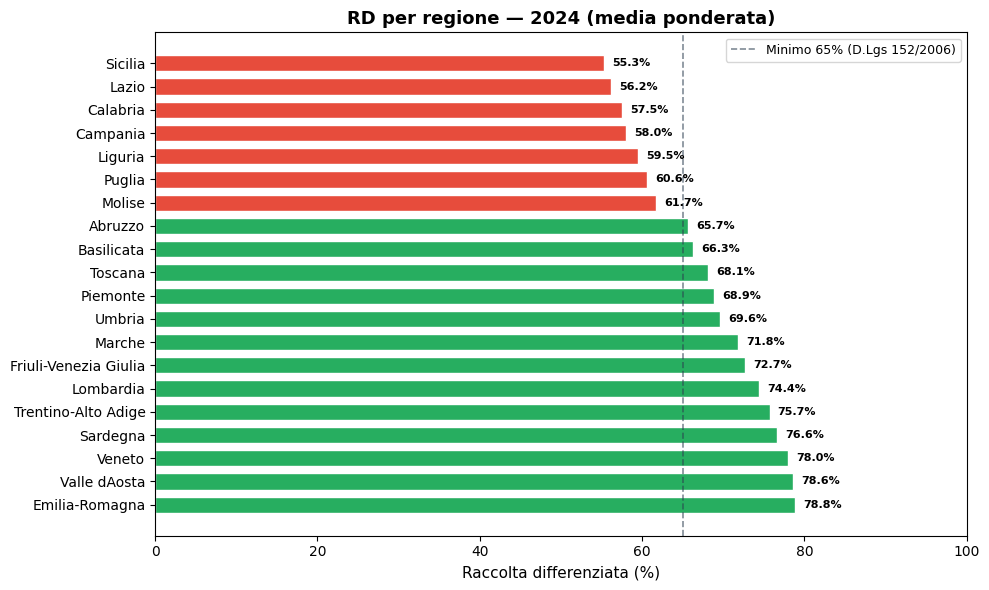

In [6]:
# Figura 2: RD per regione
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if v >= 65 else '#e74c3c' for v in df_reg['rd_pct_pesata']]
bars = ax.barh(df_reg['regione'], df_reg['rd_pct_pesata'], color=colors, edgecolor='white', height=0.7)
ax.axvline(x=65, color='#2c3e50', linestyle='--', linewidth=1.2, alpha=0.6, label='Minimo 65% (D.Lgs 152/2006)')
ax.set_xlabel('Raccolta differenziata (%)', fontsize=11)
ax.set_title('RD per regione — 2024 (media ponderata)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 100)
for bar, val in zip(bars, df_reg['rd_pct_pesata']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val}%',
            va='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_rd_per_regione.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Cross-dataset: produzione per km²

In [7]:
# Province: solo quelle con >50% dei comuni rappresentati nel join
df_prov = con.execute(f"""
    SELECT j.regione, j.provincia,
           COUNT(DISTINCT j.codice_comune_istat) as comuni_join,
           ROUND(SUM(j.totale_ru_tonnellate) / NULLIF(SUM(j.superficie_km2), 0), 0) as ru_km2,
           ROUND(SUM(j.totale_rd_tonnellate) / NULLIF(SUM(j.totale_ru_tonnellate), 0) * 100, 1) as rd_pct
    FROM joined j
    INNER JOIN (
        SELECT regione, provincia, COUNT(*) as tot
        FROM '{BASE}' WHERE anno = 2024
        GROUP BY regione, provincia
    ) t ON j.provincia = t.provincia AND j.regione = t.regione
    WHERE j.anno = 2024 AND j.popolazione > 0 AND j.superficie_km2 > 0
    GROUP BY j.regione, j.provincia, t.tot
    HAVING COUNT(DISTINCT j.codice_comune_istat) >= 0.5 * t.tot
    ORDER BY ru_km2 DESC LIMIT 15
""").df()
display(df_prov)

,regione,provincia,comuni_join,ru_km2,rd_pct
0,Campania,Napoli,91,1256.0,53.1
1,Lombardia,Milano,133,963.0,69.0
2,Lombardia,Monza e della Brianza,54,930.0,80.1
3,Valle dAosta,Aosta,1,775.0,78.6
4,Friuli-Venezia Giulia,Trieste,6,551.0,50.6
5,Lazio,Roma,110,437.0,54.0
6,Toscana,Prato,7,423.0,71.7
7,Lombardia,Varese,133,344.0,79.2
8,Emilia-Romagna,Rimini,27,270.0,69.1
9,Veneto,Padova,100,240.0,76.6


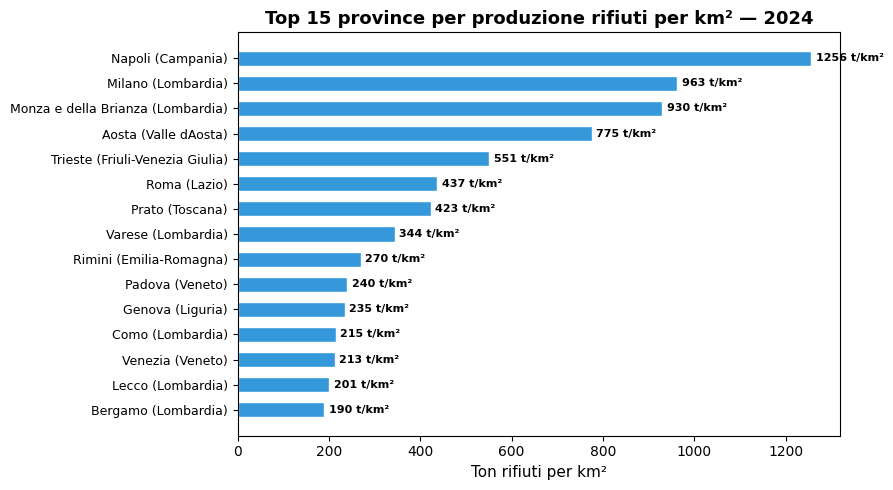

In [8]:
# Figura 3: Top province per ton/km²
fig, ax = plt.subplots(figsize=(9, 5))
labels = [f"{r['provincia']} ({r['regione']})" for _, r in df_prov.iterrows()]
bars = ax.barh(range(len(df_prov)), df_prov['ru_km2'][::-1], color='#3498db', edgecolor='white', height=0.6)
ax.set_yticks(range(len(df_prov)))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_xlabel('Ton rifiuti per km²', fontsize=11)
ax.set_title('Top 15 province per produzione rifiuti per km² — 2024', fontsize=13, fontweight='bold')
for bar, val in zip(bars, df_prov['ru_km2'][::-1]):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{int(val)} t/km²',
            va='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_top_province.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Top comuni (solo con superficie > 0.5 km² per escludere micro-comuni anomali)
df_com = con.execute("""
    SELECT j.comune, j.provincia, j.regione, j.popolazione,
           ROUND(j.superficie_km2, 2) as km2,
           ROUND(j.totale_ru_tonnellate / NULLIF(j.superficie_km2, 0), 0) as ru_km2,
           j.percentuale_rd
    FROM joined j
    WHERE j.anno = 2024 AND j.popolazione > 0 AND j.superficie_km2 > 0.5
    ORDER BY ru_km2 DESC LIMIT 20
""").df()
display(df_com)

,comune,provincia,regione,popolazione,km2,ru_km2,percentuale_rd
0,CASAVATORE,Napoli,Campania,18160,1.61,5065.0,45.10
1,PORTICI,Napoli,Campania,51351,4.64,5004.0,58.68
2,NAPOLI,Napoli,Campania,908082,119.24,4302.0,44.38
3,MELITO DI NAPOLI,Napoli,Campania,36143,3.78,4025.0,29.40
4,SAN GIORGIO A CREMANO,Napoli,Campania,41748,4.07,3659.0,58.43
5,MILANO,Milano,Lombardia,1366155,181.76,3618.0,63.33
6,TORINO,Torino,Piemonte,856745,130.00,3327.0,57.35
7,FRATTAMINORE,Napoli,Campania,15297,2.04,3039.0,51.26
8,AVERSA,Caserta,Campania,49295,8.85,3025.0,52.47
9,SANTANTIMO,Napoli,Campania,32428,5.91,2983.0,53.91


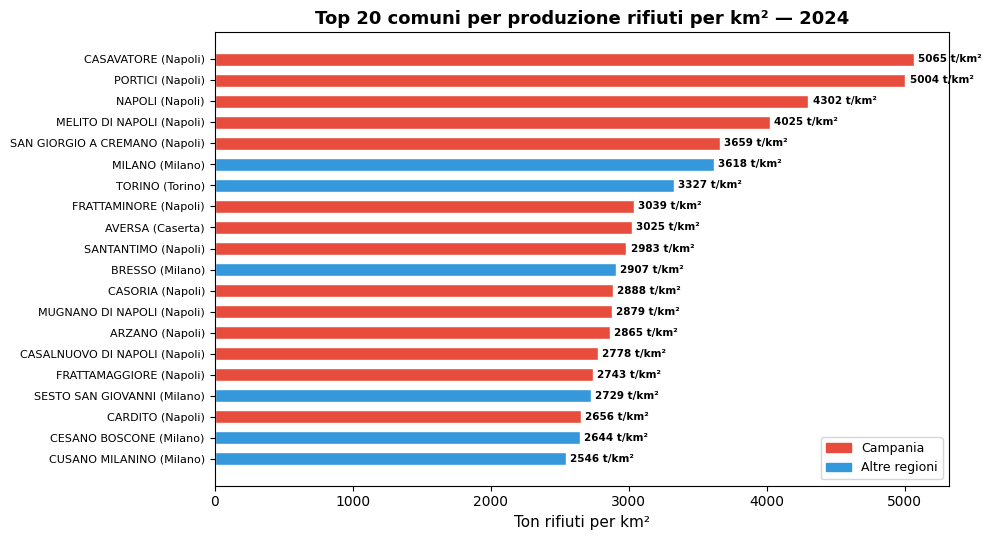

In [10]:
# Figura 4: Top comuni per ton/km²
fig, ax = plt.subplots(figsize=(10, 5.5))
y_labels = [f"{r['comune']} ({r['provincia']})" for _, r in df_com.iterrows()]
colors_com = ['#e74c3c' if r['regione'] == 'Campania' else '#3498db' for _, r in df_com.iterrows()]
bars = ax.barh(range(len(df_com)), df_com['ru_km2'][::-1], color=colors_com[::-1], edgecolor='white', height=0.6)
ax.set_yticks(range(len(df_com)))
ax.set_yticklabels(y_labels[::-1], fontsize=8)
ax.set_xlabel('Ton rifiuti per km²', fontsize=11)
ax.set_title('Top 20 comuni per produzione rifiuti per km² — 2024', fontsize=13, fontweight='bold')
ax.legend([plt.Rectangle((0,0),1,1,color='#e74c3c'), plt.Rectangle((0,0),1,1,color='#3498db')],
          ['Campania', 'Altre regioni'], fontsize=9, loc='lower right')
for bar, val in zip(bars, df_com['ru_km2'][::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f'{int(val)} t/km²',
            va='center', fontsize=7.5, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_top_comuni.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Divario territoriale: Nord Ovest · Nord Est · Centro · Sud · Isole

In [11]:
df_macro = con.execute("""
    SELECT anno,
           CASE
               WHEN regione IN ('Valle dAosta','Piemonte','Lombardia','Liguria') THEN 'Nord-Ovest'
               WHEN regione IN ('Trentino-Alto Adige','Veneto','Friuli-Venezia Giulia','Emilia-Romagna') THEN 'Nord-Est'
               WHEN regione IN ('Toscana','Umbria','Marche','Lazio') THEN 'Centro'
               WHEN regione IN ('Abruzzo','Molise','Campania','Puglia','Basilicata','Calabria') THEN 'Sud'
               ELSE 'Isole'
           END as ripartizione,
           ROUND(SUM(totale_rd_tonnellate) / NULLIF(SUM(totale_ru_tonnellate), 0) * 100, 1) as rd_pct,
           ROUND(SUM(totale_ru_tonnellate) / NULLIF(SUM(popolazione), 0) * 1000, 0) as kg_procapite
    FROM joined WHERE popolazione > 0
    GROUP BY anno, ripartizione ORDER BY ripartizione, anno
""").df()
display(df_macro)

,anno,ripartizione,rd_pct,kg_procapite
0,2020,Centro,59.2,525.0
1,2021,Centro,60.4,539.0
2,2022,Centro,61.5,533.0
3,2023,Centro,62.3,531.0
4,2024,Centro,63.2,539.0
5,2020,Isole,50.2,446.0
6,2021,Isole,54.4,466.0
7,2022,Isole,57.2,462.0
8,2023,Isole,60.4,452.0
9,2024,Isole,60.8,458.0


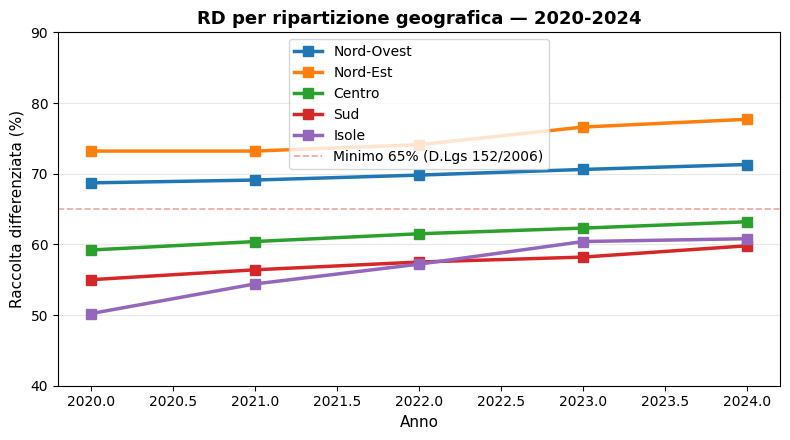

In [12]:
# Figura 5: RD per ripartizione
fig, ax = plt.subplots(figsize=(8, 4.5))
for area in ['Nord-Ovest', 'Nord-Est', 'Centro', 'Sud', 'Isole']:
    d = df_macro[df_macro['ripartizione'] == area]
    if not d.empty:
        ax.plot(d['anno'], d['rd_pct'], marker='s', linewidth=2.5, markersize=7, label=area)
ax.axhline(y=65, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.5, label='Minimo 65% (D.Lgs 152/2006)')
ax.set_ylim(40, 90)
ax.set_xlabel('Anno', fontsize=11)
ax.set_ylabel('Raccolta differenziata (%)', fontsize=11)
ax.set_title('RD per ripartizione geografica — 2020-2024', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_macroarea_rd.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. RD % vs produzione pro-capite

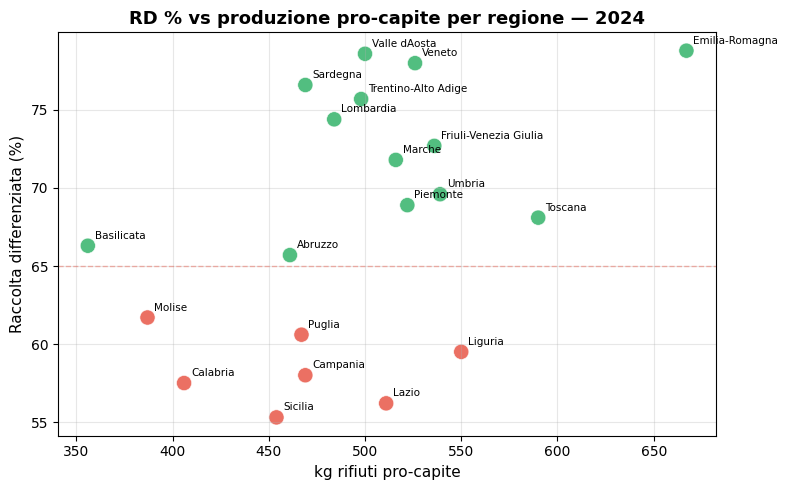

In [13]:
# Figura 6: RD % vs kg pro-capite per regione
fig, ax = plt.subplots(figsize=(8, 5))
colors_scatter = ['#27ae60' if v >= 65 else '#e74c3c' for v in df_reg['rd_pct_pesata']]
ax.scatter(df_reg['kg_procapite'], df_reg['rd_pct_pesata'], c=colors_scatter, s=120, alpha=0.8, edgecolors='white', linewidth=0.5)
for _, r in df_reg.iterrows():
    ax.annotate(r['regione'], (r['kg_procapite'], r['rd_pct_pesata']),
                textcoords="offset points", xytext=(5, 5), fontsize=7.5)
ax.axhline(y=65, color='#e74c3c', linestyle='--', linewidth=1, alpha=0.4)
ax.set_xlabel('kg rifiuti pro-capite', fontsize=11)
ax.set_ylabel('Raccolta differenziata (%)', fontsize=11)
ax.set_title('RD % vs produzione pro-capite per regione — 2024', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / 'rifiuti-km2_rd_vs_procapite.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Regioni con la crescita più rapida

In [14]:
df_2020 = con.execute("""
    SELECT regione,
           ROUND(SUM(totale_rd_tonnellate) / NULLIF(SUM(totale_ru_tonnellate), 0) * 100, 1) as rd_2020
    FROM joined WHERE anno = 2020 AND popolazione > 0
    GROUP BY regione
""").df()
df_2024 = con.execute("""
    SELECT regione,
           ROUND(SUM(totale_rd_tonnellate) / NULLIF(SUM(totale_ru_tonnellate), 0) * 100, 1) as rd_2024
    FROM joined WHERE anno = 2024 AND popolazione > 0
    GROUP BY regione
""").df()
df_crescita = df_2020.merge(df_2024, on='regione')
df_crescita['delta'] = (df_crescita['rd_2024'] - df_crescita['rd_2020']).round(1)
df_crescita = df_crescita.sort_values('delta', ascending=False)
display(df_crescita)

,regione,rd_2020,rd_2024,delta
5,Sicilia,42.1,55.3,13.2
18,Valle dAosta,66.0,78.6,12.6
17,Basilicata,55.0,66.3,11.3
1,Emilia-Romagna,72.0,78.8,6.8
4,Puglia,54.3,60.6,6.3
6,Liguria,53.3,59.5,6.2
3,Molise,55.5,61.7,6.2
12,Toscana,62.2,68.1,5.9
9,Calabria,51.6,57.5,5.9
0,Piemonte,64.2,68.9,4.7


In [15]:
# Verifica finale: quanti comuni persi dal join?
df_totali = con.execute(f"""SELECT COUNT(DISTINCT codice_comune_istat) as tot FROM '{BASE}' WHERE anno = 2024""").fetchone()[0]
df_ok = con.execute("SELECT COUNT(DISTINCT codice_comune_istat) as ok FROM joined WHERE anno = 2024").fetchone()[0]
print(f"Comuni ISPRA 2024: {df_totali}")
print(f"Comuni nel join:  {df_ok}")
print(f"Copertura:        {df_ok/df_totali*100:.2f}%")

Comuni ISPRA 2024: 7671
Comuni nel join:  7667
Copertura:        99.95%


---
Notebook generato con dati pubblici da GCS (`gs://dataciviclab-clean/`).
Join: codice ISTAT (6 char) per non-Sardegna, nome normalizzato per Sardegna.